setup

In [ ]:
# Core Python Libraries
import os
import sys
import time
import warnings
import random

import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series Analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Auto ARIMA
!pip install pmdarima # Install pmdarima
from pmdarima import auto_arima

# Prophet Forecasting
from prophet import Prophet

# Deep Learning (LSTM)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Utility Libraries
from tqdm import tqdm

# Global COnfiguration

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot styling for publication-quality figures
sns.set_theme(style="whitegrid", palette="deep")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.dpi"] = 120

# Helper Functions

def rmse(y_true, y_pred):
    """Compute Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mae(y_true, y_pred):
    """Compute Mean Absolute Error"""
    return mean_absolute_error(y_true, y_pred)


def model_metrics(y_true, y_pred, model_name):
    """Return evaluation metrics as dataframe"""

    metrics = pd.DataFrame({
        "Model":[model_name],
        "MAE":[mae(y_true,y_pred)],
        "RMSE":[rmse(y_true,y_pred)]
    })

    return metrics

print("Environment setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.9 MB/s eta 0:00:00
Environment setup complete.


output folder

In [ ]:
# Root directory for all outputs
PROJECT_ROOT = "project_outputs"

# Folder structure following STDA temporal pipeline
folders = {
    "preprocessing": "Data cleaning, dataset statistics, and feature engineering outputs",
    "eda": "Exploratory data analysis plots and distributions",
    "temporal_analysis": "Trend analysis, decomposition, seasonal patterns",
    "stationarity": "ADF/KPSS test outputs and stationarity diagnostics",
    "autocorrelation": "ACF/PACF plots and temporal correlation analysis",
    "forecasting": "Forecast outputs from ARIMA, SARIMA, Prophet",
    "deep_learning": "LSTM model results and training diagnostics",
    "evaluation": "Model performance metrics and comparison plots",
    "tables": "CSV tables used in report (metrics, statistics)",
    "figures": "Final figures used directly in IEEE report"
}

# Create main directory
os.makedirs(PROJECT_ROOT, exist_ok=True)

# Create subdirectories
for folder in folders:
    path = os.path.join(PROJECT_ROOT, folder)
    os.makedirs(path, exist_ok=True)

print("Project directory structure created successfully.\n")

# Display folder structure
for folder, description in folders.items():
    print(f"{folder}/  -->  {description}")

Project directory structure created successfully.

preprocessing/  -->  Data cleaning, dataset statistics, and feature engineering outputs
eda/  -->  Exploratory data analysis plots and distributions
temporal_analysis/  -->  Trend analysis, decomposition, seasonal patterns
stationarity/  -->  ADF/KPSS test outputs and stationarity diagnostics
autocorrelation/  -->  ACF/PACF plots and temporal correlation analysis
forecasting/  -->  Forecast outputs from ARIMA, SARIMA, Prophet
deep_learning/  -->  LSTM model results and training diagnostics
evaluation/  -->  Model performance metrics and comparison plots
tables/  -->  CSV tables used in report (metrics, statistics)
figures/  -->  Final figures used directly in IEEE report


Loading Dataset

In [ ]:
print("Loading dataset...\n")

start_time = time.time()

DATA_PATH = "WeatherEvents.csv"

# file validation
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at path: {DATA_PATH}")

# load dataset
df = pd.read_csv(DATA_PATH)

load_time = time.time() - start_time

print(f"Dataset loaded successfully in {load_time:.2f} seconds\n")

# convert timestamp columns
datetime_columns = ["StartTime(UTC)", "EndTime(UTC)"]

for col in datetime_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# sort by time
df = df.sort_values("StartTime(UTC)")

#set time index
df = df.set_index("StartTime(UTC)")

#dataset shape
print("Dataset Shape:", df.shape)

# dataset info
print("\nDataset Info:")
print(df.info())

# missing value analysis
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values
})

missing_table = missing_table[missing_table["Missing Values"] > 0]

missing_table.to_csv(
    os.path.join(PROJECT_ROOT, "tables", "missing_values.csv"),
    index=False
)

print("\nMissing values summary saved.")

# memory usage analysis
memory_usage = df.memory_usage(deep=True).sum() / (1024**2)

print(f"\nTotal Memory Usage: {memory_usage:.2f} MB")

# dataset statistics
dataset_summary = df.describe(include="all")

dataset_summary.to_csv(
    os.path.join(PROJECT_ROOT, "tables", "dataset_summary_statistics.csv")
)

print("\nDataset statistics saved.")

# Preview Data
display(df.head())

Loading dataset...

Dataset loaded successfully in 1.90 seconds

Dataset Shape: (370960, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 370960 entries, 2016-01-01 05:01:00 to 2022-12-31 23:15:00
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   EventId            370960 non-null  object        
 1   Type               370960 non-null  object        
 2   Severity           370960 non-null  object        
 3   EndTime(UTC)       370960 non-null  datetime64[ns]
 4   Precipitation(in)  370960 non-null  float64       
 5   TimeZone           370960 non-null  object        
 6   AirportCode        370960 non-null  object        
 7   LocationLat        370960 non-null  float64       
 8   LocationLng        370960 non-null  float64       
 9   City               367324 non-null  object        
 10  County             370960 non-null  object        
 11  State         

,EventId,Type,Severity,EndTime(UTC),Precipitation(in),TimeZone,AirportCode,LocationLat,LocationLng,City,County,State,ZipCode
StartTime(UTC),,,,,,,,,,,,,
2016-01-01 05:01:00,W-333943,Snow,Light,2016-01-01 11:53:00,0.06,US/Eastern,KCMX,47.1660,-88.4807,Calumet,Houghton,MI,49913.0
2016-01-01 05:35:00,W-317225,Rain,Light,2016-01-01 05:55:00,0.00,US/Eastern,KJES,31.5540,-81.8825,Jesup,Wayne,GA,31546.0
2016-01-01 05:44:00,W-245899,Snow,Light,2016-01-01 14:53:00,0.01,US/Eastern,KMSS,44.9358,-74.8455,Massena,St. Lawrence,NY,13662.0
2016-01-01 05:50:00,W-310697,Fog,Severe,2016-01-01 06:12:00,0.00,US/Eastern,KBLF,37.2958,-81.2077,Bluefield,Mercer,WV,24701.0
2016-01-01 05:53:00,W-70964,Cold,Severe,2016-01-04 15:17:00,0.00,US/Eastern,KWST,41.3509,-71.8054,Westerly,Washington,RI,2891.0


data cleaning and validation

In [ ]:
print("Starting data cleaning...\n")

initial_rows = df.shape[0]

# removing duplicate records
duplicate_count = df.duplicated().sum()

df = df.drop_duplicates()

print(f"Duplicates removed: {duplicate_count}")

#remove missing coordinates
missing_coords = df[["LocationLat","LocationLng"]].isnull().sum().sum()

df = df.dropna(subset=["LocationLat","LocationLng"])

print(f"Rows removed due to missing coordinates: {missing_coords}")

#validating geographic coordinates
valid_lat = df["LocationLat"].between(-90,90)
valid_lon = df["LocationLng"].between(-180,180)

invalid_geo = (~valid_lat | ~valid_lon).sum()

df = df[valid_lat & valid_lon]

print(f"Invalid geographic rows removed: {invalid_geo}")

# removing invalid time records
invalid_time = (df["EndTime(UTC)"] < df.index).sum()

df = df[df["EndTime(UTC)"] >= df.index]

print(f"Invalid time records removed: {invalid_time}")

# event duration minutes
df["EventDuration_min"] = (
    df["EndTime(UTC)"] - df.index
).dt.total_seconds() / 60

# Remove negative durations
negative_duration = (df["EventDuration_min"] < 0).sum()

df = df[df["EventDuration_min"] >= 0]

print(f"Negative duration events removed: {negative_duration}")

# final dataset size
final_rows = df.shape[0]

print(f"\nInitial rows: {initial_rows}")
print(f"Final rows after cleaning: {final_rows}")

#cleaning summary table
cleaning_summary = pd.DataFrame({
    "Step":[
        "Initial Dataset",
        "Duplicate Removal",
        "Missing Coordinates Removed",
        "Invalid Geographic Coordinates Removed",
        "Invalid Time Records Removed",
        "Negative Duration Removed",
        "Final Dataset"
    ],
    "Rows":[
        initial_rows,
        duplicate_count,
        missing_coords,
        invalid_geo,
        invalid_time,
        negative_duration,
        final_rows
    ]
})

cleaning_summary.to_csv(
    os.path.join(PROJECT_ROOT,"tables","cleaning_summary.csv"),
    index=False
)

print("\nCleaning summary saved.")

#saving clean dataset
df.to_csv(
    os.path.join(PROJECT_ROOT,"preprocessing","clean_dataset.csv")
)

print("Clean dataset saved.")

display(cleaning_summary)

Starting data cleaning...

Duplicates removed: 0
Rows removed due to missing coordinates: 0
Invalid geographic rows removed: 0
Invalid time records removed: 0
Negative duration events removed: 0

Initial rows: 370960
Final rows after cleaning: 370960

Cleaning summary saved.
Clean dataset saved.


,Step,Rows
0,Initial Dataset,370960
1,Duplicate Removal,0
2,Missing Coordinates Removed,0
3,Invalid Geographic Coordinates Removed,0
4,Invalid Time Records Removed,0
5,Negative Duration Removed,0
6,Final Dataset,370960


temporal feature engineering

In [ ]:
print("Generating temporal features...\n")

# basic time components
df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["week_of_year"] = df.index.isocalendar().week.astype(int)
df["quarter"] = df.index.quarter

# weekend indicator
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

# season classification
def assign_season(month):

    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["month"].apply(assign_season)

# time of day category
def hour_category(hour):

    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["time_of_day"] = df["hour"].apply(hour_category)

# Cyclical Encoding (important for ML models)
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df["dow_sin"] = np.sin(2*np.pi*df["day_of_week"]/7)
df["dow_cos"] = np.cos(2*np.pi*df["day_of_week"]/7)

# temporal feature summary table
temporal_summary = pd.DataFrame({
    "Feature":[
        "year","month","day","hour",
        "day_of_week","week_of_year",
        "quarter","is_weekend",
        "season","time_of_day"
    ],
    "Description":[
        "Calendar year",
        "Month of year",
        "Day of month",
        "Hour of day",
        "Day of week (0=Mon)",
        "ISO week number",
        "Quarter of year",
        "Weekend indicator",
        "Season category",
        "Daily time segment"
    ]
})

temporal_summary.to_csv(
    os.path.join(PROJECT_ROOT,"tables","temporal_features_description.csv"),
    index=False
)

print("Temporal feature engineering completed.")

display(df.head())

Generating temporal features...

Temporal feature engineering completed.


,EventId,Type,Severity,EndTime(UTC),Precipitation(in),TimeZone,AirportCode,LocationLat,LocationLng,City,...,quarter,is_weekend,season,time_of_day,month_sin,month_cos,hour_sin,hour_cos,dow_sin,dow_cos
StartTime(UTC),,,,,,,,,,,,,,,,,,,,,
2016-01-01 05:01:00,W-333943,Snow,Light,2016-01-01 11:53:00,0.06,US/Eastern,KCMX,47.1660,-88.4807,Calumet,...,1,0,Winter,Morning,0.5,0.866025,0.965926,0.258819,-0.433884,-0.900969
2016-01-01 05:35:00,W-317225,Rain,Light,2016-01-01 05:55:00,0.00,US/Eastern,KJES,31.5540,-81.8825,Jesup,...,1,0,Winter,Morning,0.5,0.866025,0.965926,0.258819,-0.433884,-0.900969
2016-01-01 05:44:00,W-245899,Snow,Light,2016-01-01 14:53:00,0.01,US/Eastern,KMSS,44.9358,-74.8455,Massena,...,1,0,Winter,Morning,0.5,0.866025,0.965926,0.258819,-0.433884,-0.900969
2016-01-01 05:50:00,W-310697,Fog,Severe,2016-01-01 06:12:00,0.00,US/Eastern,KBLF,37.2958,-81.2077,Bluefield,...,1,0,Winter,Morning,0.5,0.866025,0.965926,0.258819,-0.433884,-0.900969
2016-01-01 05:53:00,W-70964,Cold,Severe,2016-01-04 15:17:00,0.00,US/Eastern,KWST,41.3509,-71.8054,Westerly,...,1,0,Winter,Morning,0.5,0.866025,0.965926,0.258819,-0.433884,-0.900969


EDA

Starting Exploratory Data Analysis...



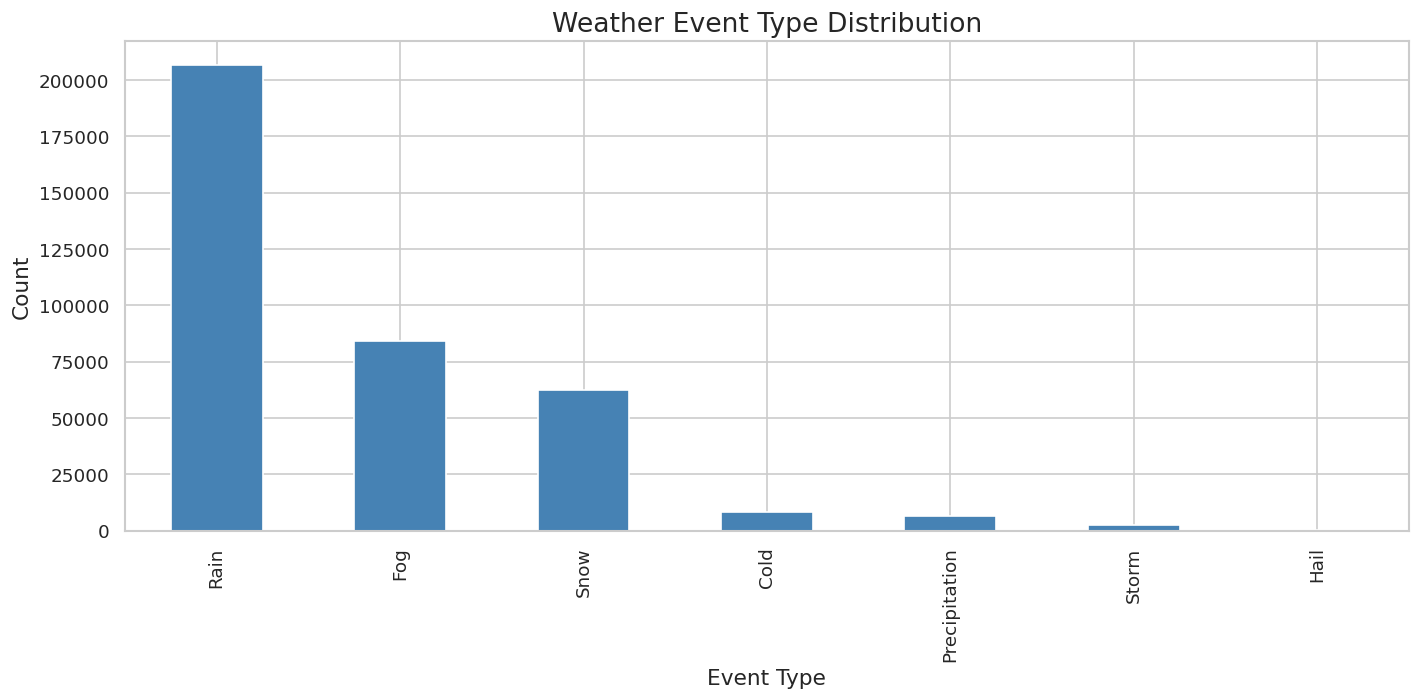

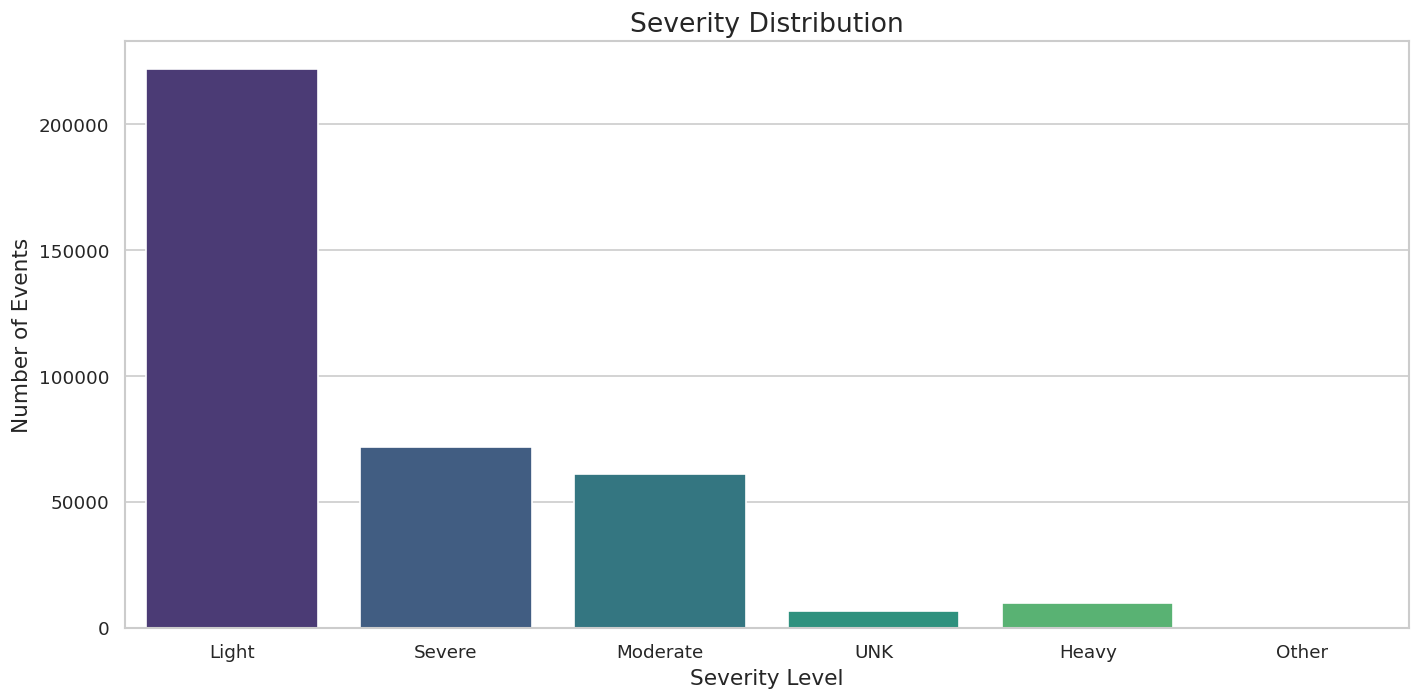

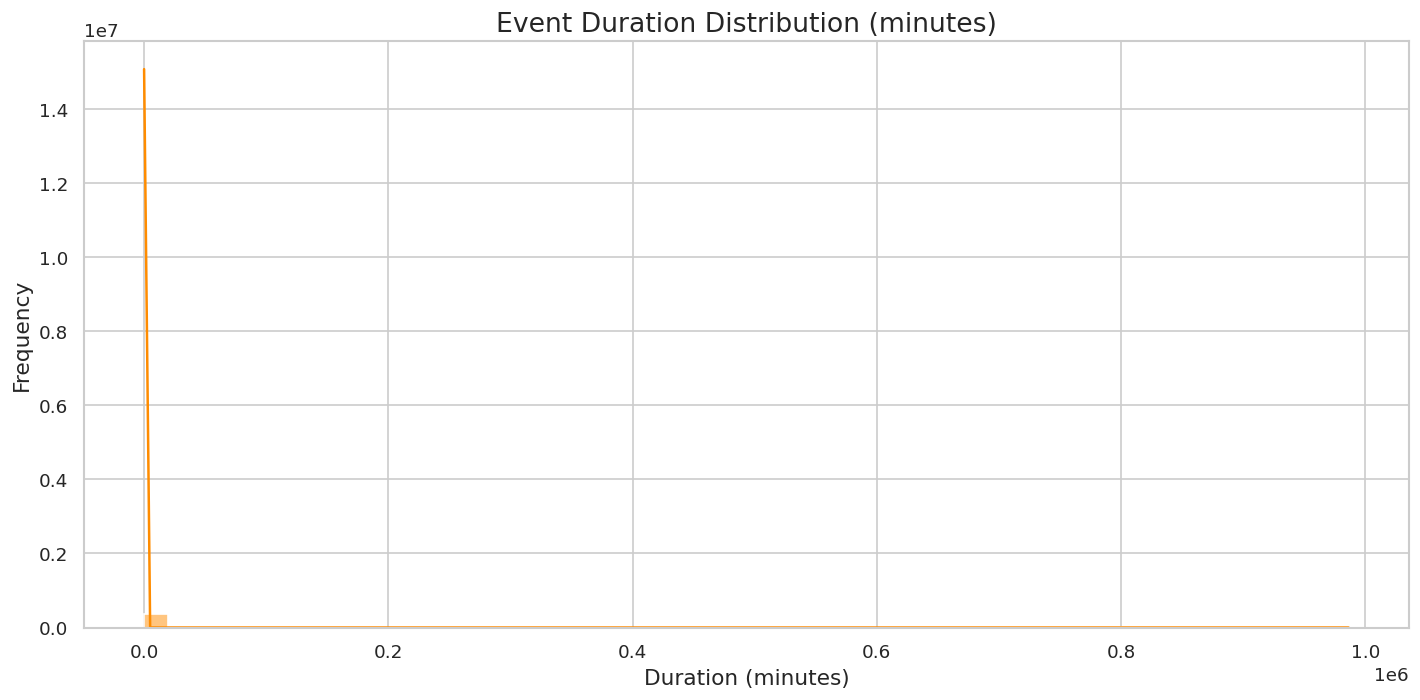

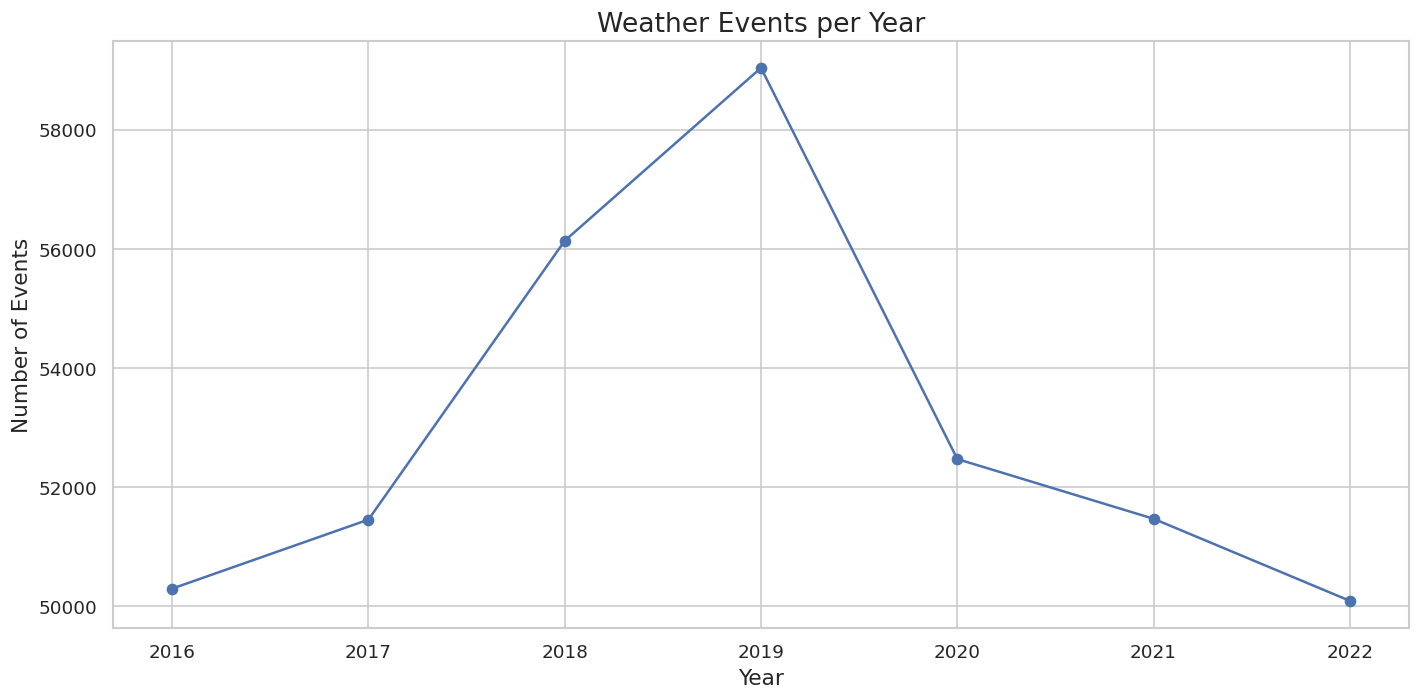

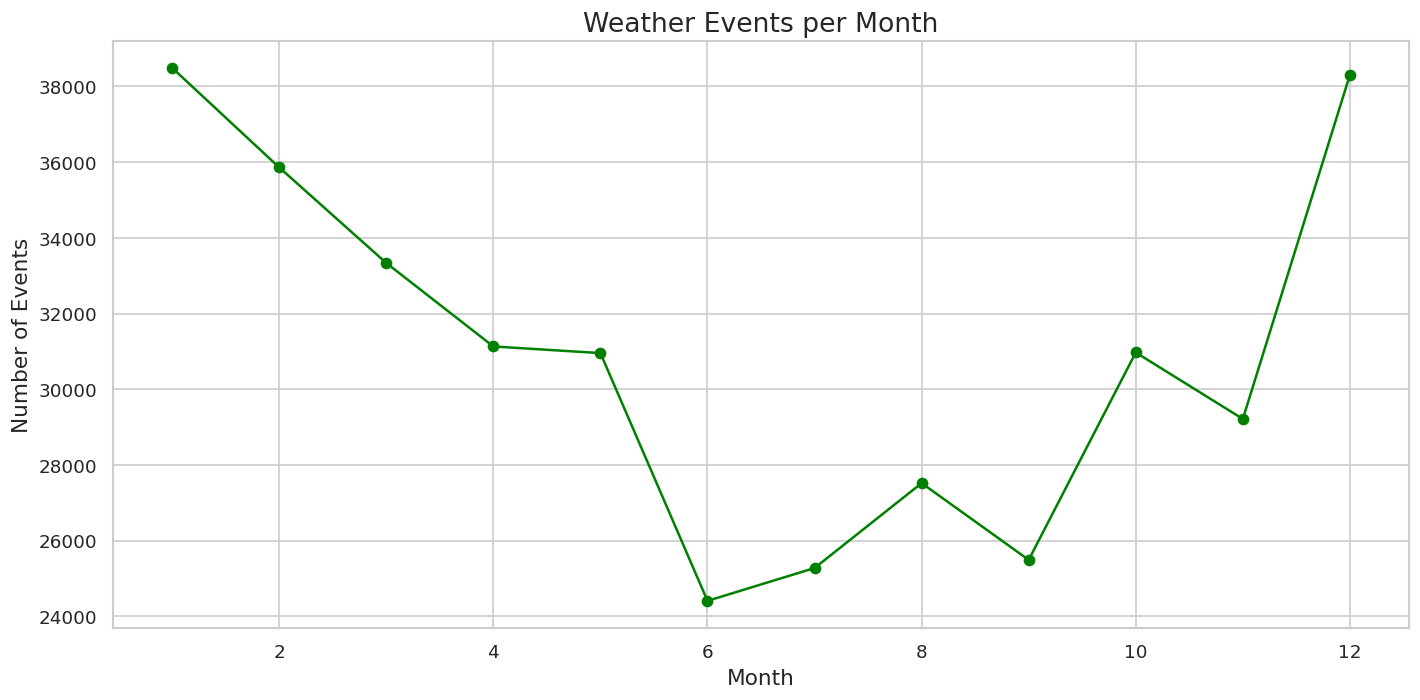

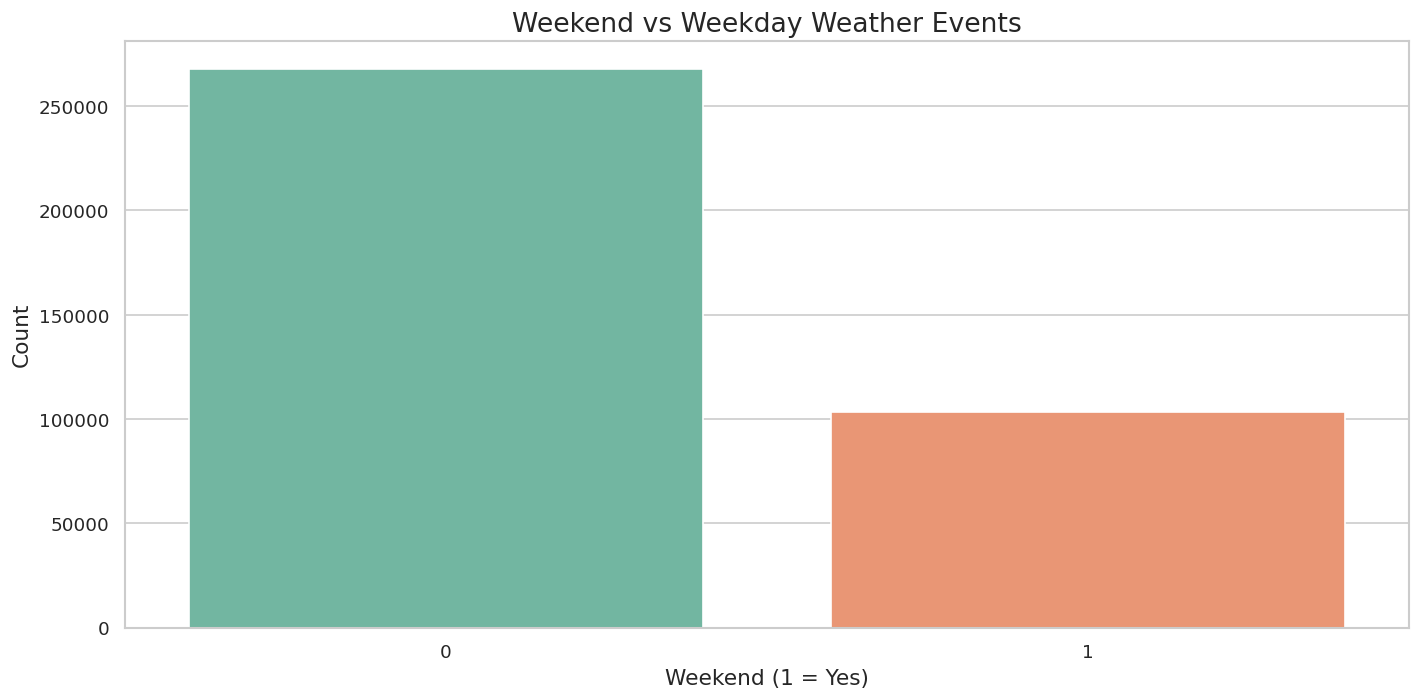

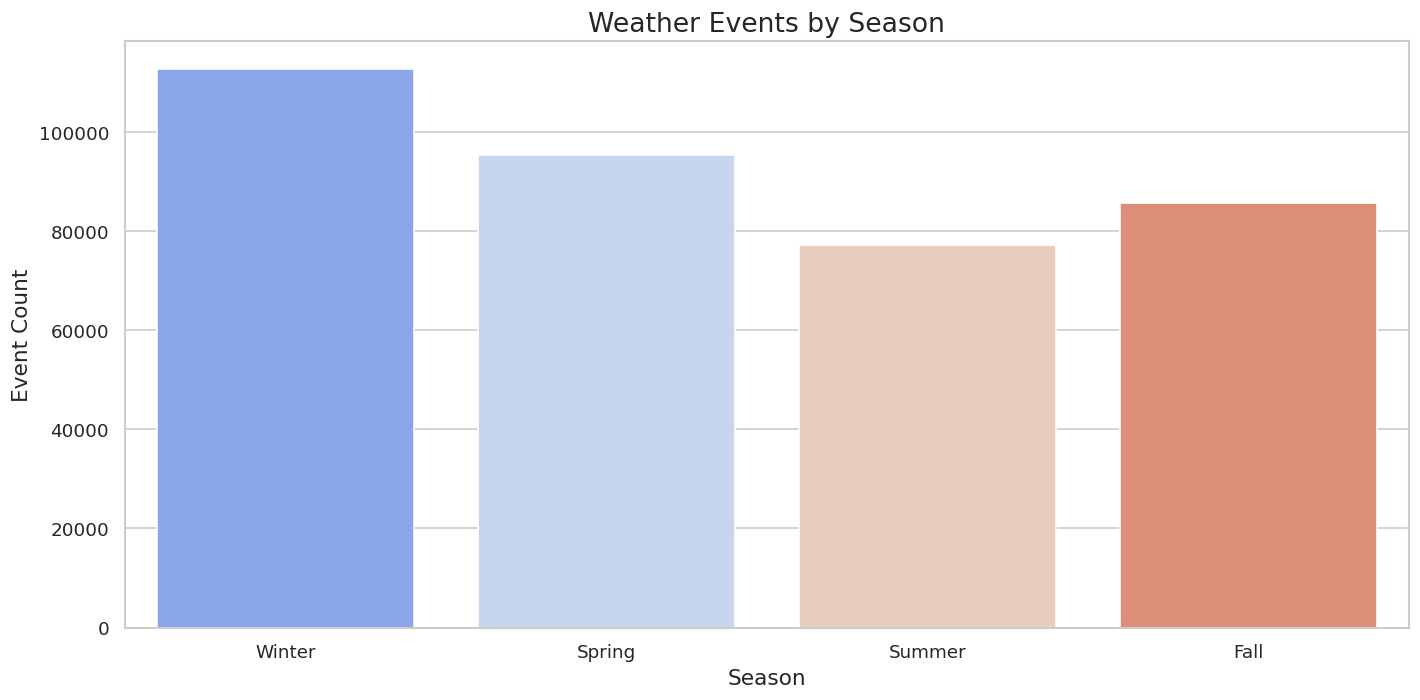

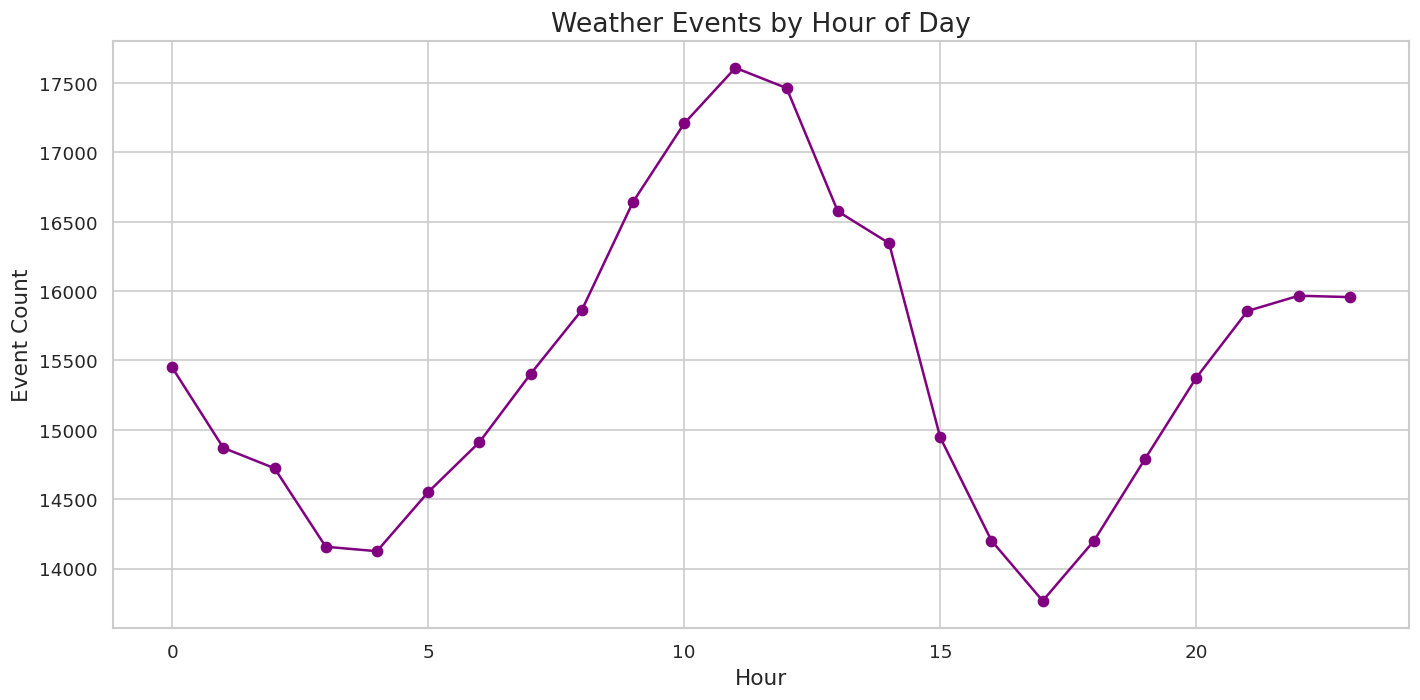

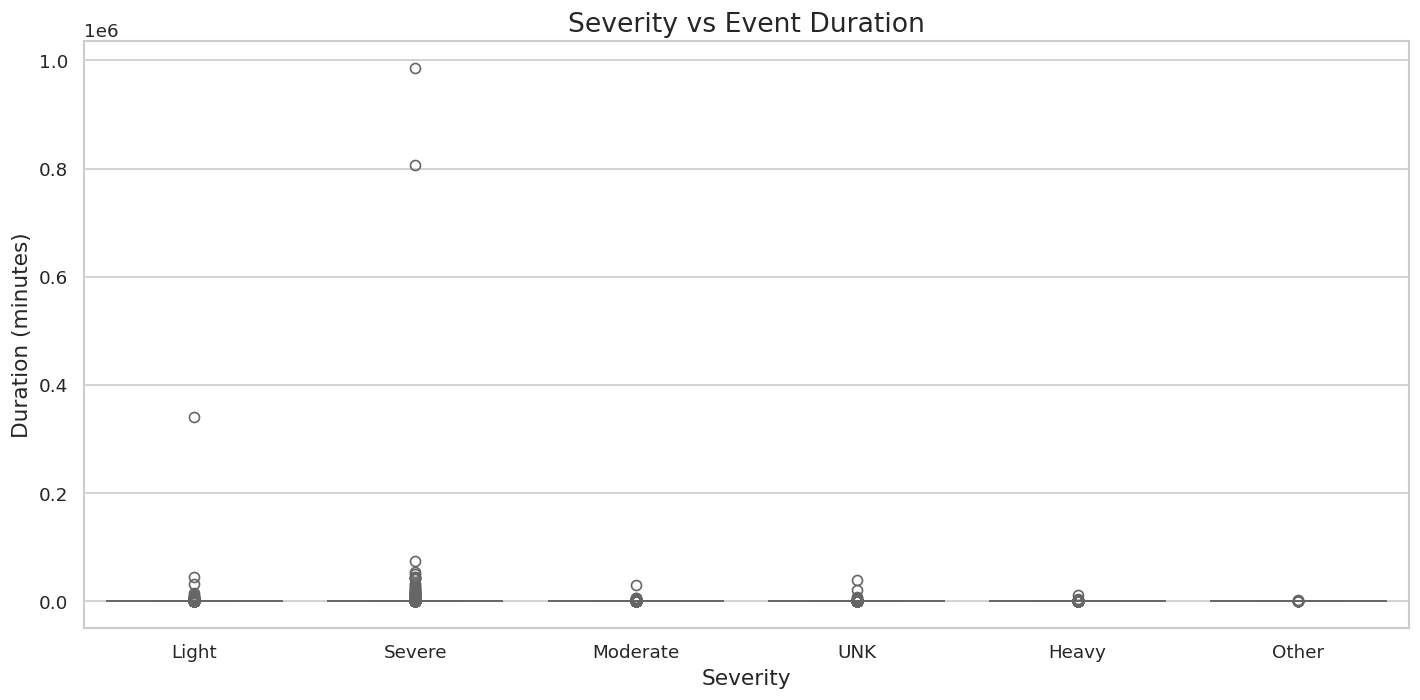

EDA summary table saved.


In [ ]:
print("Starting Exploratory Data Analysis...\n")

# event type distribution
plt.figure()

df["Type"].value_counts().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Weather Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"eda","event_type_distribution.png")
)

plt.show()


#severity distribution
plt.figure()

sns.countplot(
    x="Severity",
    data=df,
    palette="viridis"
)

plt.title("Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Events")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"eda","severity_distribution.png")
)

plt.show()


#event duration distribution
plt.figure()

sns.histplot(
    df["EventDuration_min"],
    bins=50,
    kde=True,
    color="darkorange"
)

plt.title("Event Duration Distribution (minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"eda","event_duration_distribution.png")
)

plt.show()


# events per year
year_counts = df["year"].value_counts().sort_index()

plt.figure()

year_counts.plot(
    marker="o"
)

plt.title("Weather Events per Year")
plt.xlabel("Year")
plt.ylabel("Number of Events")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"eda","events_per_year.png")
)

plt.show()


# events per month
month_counts = df["month"].value_counts().sort_index()

plt.figure()

month_counts.plot(
    marker="o",
    color="green"
)

plt.title("Weather Events per Month")
plt.xlabel("Month")
plt.ylabel("Number of Events")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"eda","events_per_month.png")
)

plt.show()


# weekend vs weekday events
plt.figure()

sns.countplot(
    x="is_weekend",
    data=df,
    palette="Set2"
)

plt.title("Weekend vs Weekday Weather Events")
plt.xlabel("Weekend (1 = Yes)")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"eda","weekend_events.png")
)

plt.show()


# season distribution
plt.figure()

sns.countplot(
    x="season",
    data=df,
    order=["Winter","Spring","Summer","Fall"],
    palette="coolwarm"
)

plt.title("Weather Events by Season")
plt.xlabel("Season")
plt.ylabel("Event Count")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"eda","season_distribution.png")
)

plt.show()


# hourly event distribution
hour_counts = df["hour"].value_counts().sort_index()

plt.figure()

hour_counts.plot(
    marker="o",
    color="purple"
)

plt.title("Weather Events by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Event Count")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"eda","hourly_distribution.png")
)

plt.show()


# severity vs duration
plt.figure()

sns.boxplot(
    x="Severity",
    y="EventDuration_min",
    data=df,
    palette="Set3"
)

plt.title("Severity vs Event Duration")
plt.xlabel("Severity")
plt.ylabel("Duration (minutes)")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"eda","severity_vs_duration.png")
)

plt.show()


# saving eda summary table
eda_summary = pd.DataFrame({

    "Metric":[
        "Total Events",
        "Unique Event Types",
        "Average Duration (minutes)",
        "Maximum Duration (minutes)"
    ],

    "Value":[
        df.shape[0],
        df["Type"].nunique(),
        df["EventDuration_min"].mean(),
        df["EventDuration_min"].max()
    ]

})

eda_summary.to_csv(
    os.path.join(PROJECT_ROOT,"tables","eda_summary.csv"),
    index=False
)

print("EDA summary table saved.")

building time series

Building time series datasets...

Daily time series created.
Weekly time series created.
Monthly time series created.
Time series summary saved.


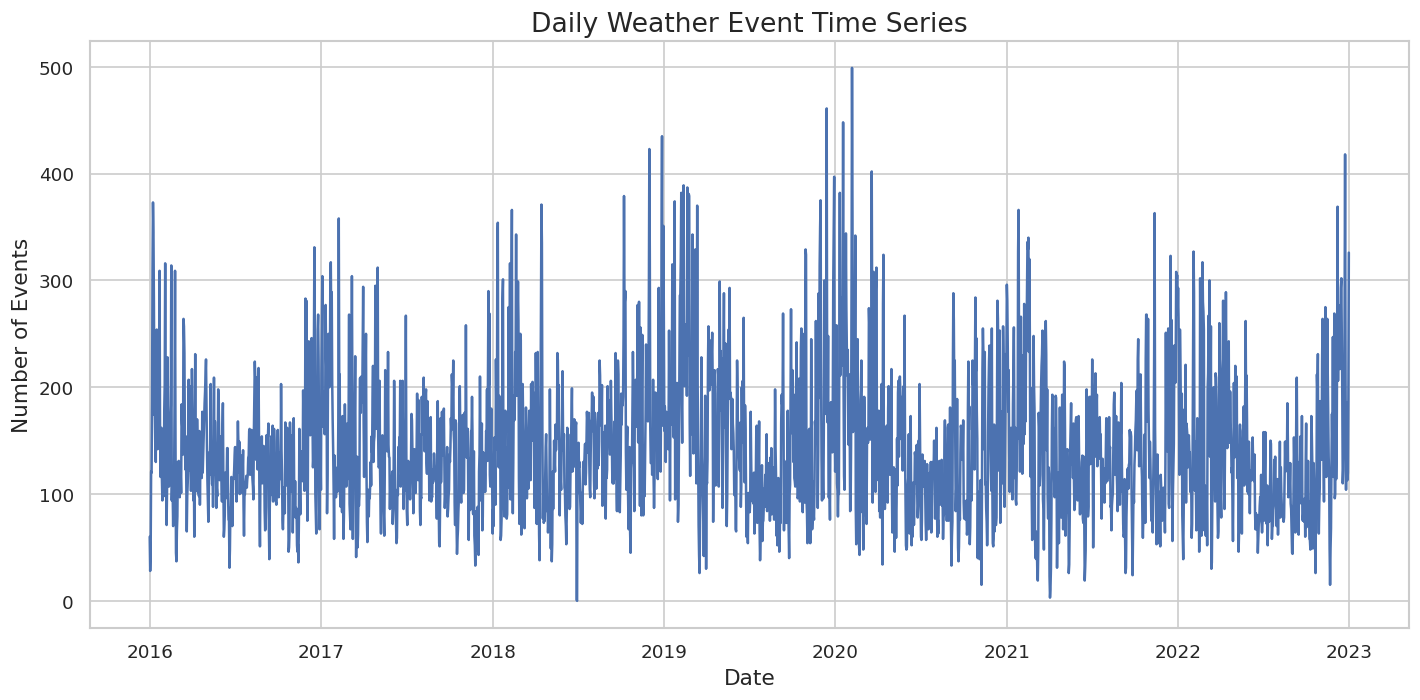

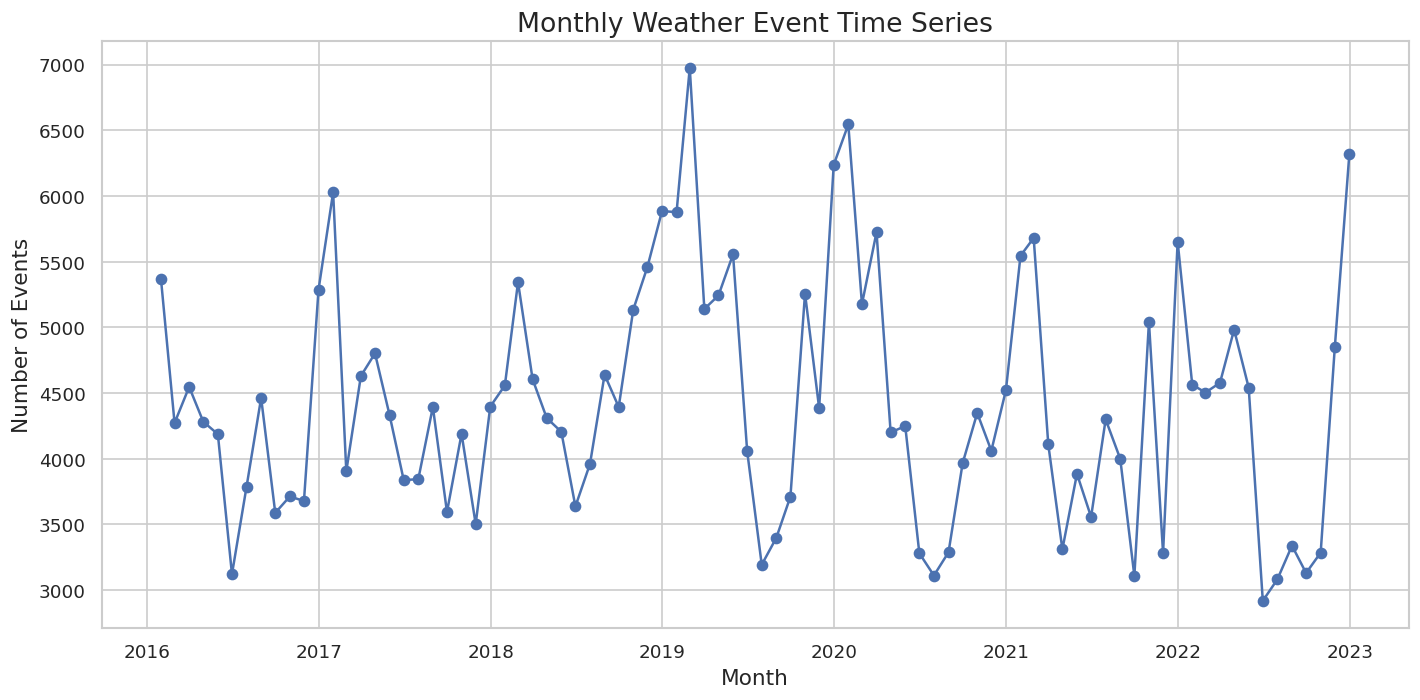

Time series construction complete.


In [ ]:
print("Building time series datasets...\n")

# daily event counts
daily_events = df.resample("D").size()
daily_events.name = "EventCount"

# Ensure continuous time index
daily_events = daily_events.asfreq("D").fillna(0)

daily_events.to_csv(
    os.path.join(PROJECT_ROOT,"tables","daily_event_counts.csv")
)

print("Daily time series created.")


# weekly event counts
weekly_events = df.resample("W").size()
weekly_events.name = "EventCount"

weekly_events.to_csv(
    os.path.join(PROJECT_ROOT,"tables","weekly_event_counts.csv")
)

print("Weekly time series created.")


# monthly event counts
monthly_events = df.resample("M").size()
monthly_events.name = "EventCount"

monthly_events.to_csv(
    os.path.join(PROJECT_ROOT,"tables","monthly_event_counts.csv")
)

print("Monthly time series created.")


# ts summary statistics
ts_summary = pd.DataFrame({

    "Metric":[
        "Total Days",
        "Average Daily Events",
        "Maximum Daily Events",
        "Minimum Daily Events"
    ],

    "Value":[
        len(daily_events),
        daily_events.mean(),
        daily_events.max(),
        daily_events.min()
    ]

})

ts_summary.to_csv(
    os.path.join(PROJECT_ROOT,"tables","timeseries_summary.csv"),
    index=False
)

print("Time series summary saved.")


# daily event ts
plt.figure()

plt.plot(daily_events)

plt.title("Daily Weather Event Time Series")
plt.xlabel("Date")
plt.ylabel("Number of Events")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"temporal_analysis","daily_timeseries.png")
)

plt.show()


# monthly ts
plt.figure()

plt.plot(monthly_events, marker="o")

plt.title("Monthly Weather Event Time Series")
plt.xlabel("Month")
plt.ylabel("Number of Events")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"temporal_analysis","monthly_timeseries.png")
)

plt.show()


print("Time series construction complete.")

temporal trend analysis

monthly trend

Performing monthly temporal trend analysis...

Monthly event counts saved.


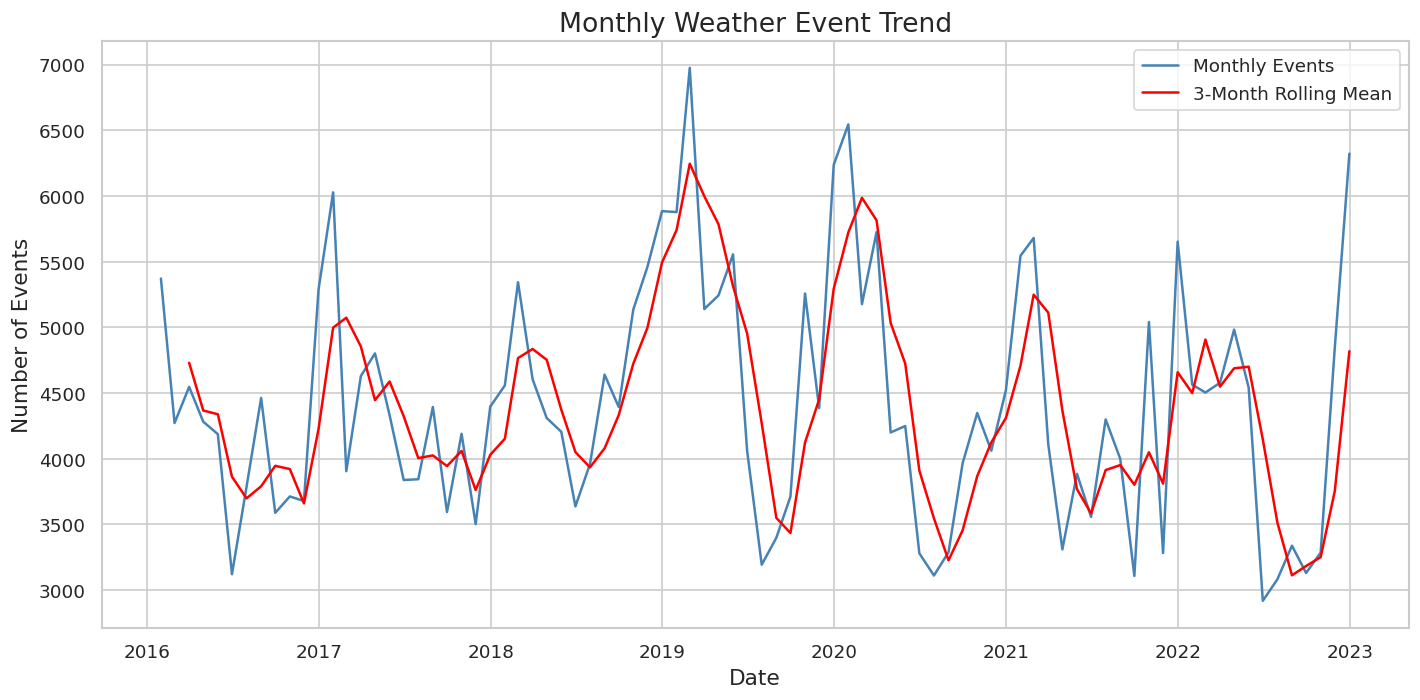

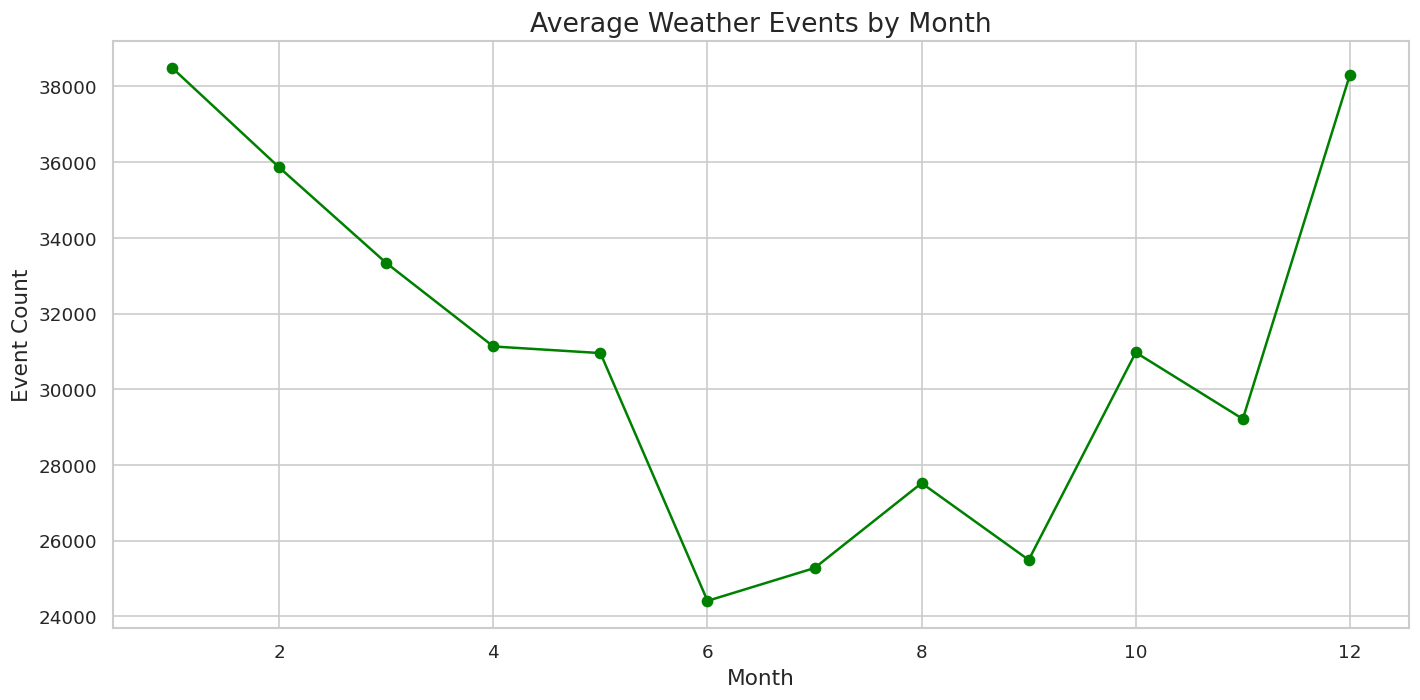

Monthly statistics saved.
Monthly temporal trend analysis complete.


In [ ]:
print("Performing monthly temporal trend analysis...\n")

# monthly event counts
monthly_events = df.resample("M").size()
monthly_events.name = "EventCount"

# Ensure continuous monthly index
monthly_events = monthly_events.asfreq("M").fillna(0)

monthly_events.to_csv(
    os.path.join(PROJECT_ROOT,"tables","monthly_event_counts.csv")
)

print("Monthly event counts saved.")


# trend smoothing - rolling mean
rolling_mean = monthly_events.rolling(window=3).mean()

# Save rolling statistics
rolling_df = pd.DataFrame({
    "EventCount": monthly_events,
    "RollingMean_3M": rolling_mean
})

rolling_df.to_csv(
    os.path.join(PROJECT_ROOT,"tables","monthly_rolling_trend.csv")
)


# monthly trend plot
plt.figure()

plt.plot(
    monthly_events,
    label="Monthly Events",
    color="steelblue"
)

plt.plot(
    rolling_mean,
    label="3-Month Rolling Mean",
    color="red"
)

plt.title("Monthly Weather Event Trend")
plt.xlabel("Date")
plt.ylabel("Number of Events")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"temporal_analysis","monthly_trend.png")
)

plt.show()


# monthly seasonal plot
monthly_avg = df.groupby("month").size()

plt.figure()

monthly_avg.plot(
    marker="o",
    color="green"
)

plt.title("Average Weather Events by Month")
plt.xlabel("Month")
plt.ylabel("Event Count")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"temporal_analysis","monthly_seasonality.png")
)

plt.show()


# monthly statistics table
monthly_stats = pd.DataFrame({

    "Metric":[
        "Total Months",
        "Average Monthly Events",
        "Maximum Monthly Events",
        "Minimum Monthly Events"
    ],

    "Value":[
        len(monthly_events),
        monthly_events.mean(),
        monthly_events.max(),
        monthly_events.min()
    ]

})

monthly_stats.to_csv(
    os.path.join(PROJECT_ROOT,"tables","monthly_statistics.csv"),
    index=False
)

print("Monthly statistics saved.")

print("Monthly temporal trend analysis complete.")

daily trend

Performing daily temporal trend analysis...

Rolling trend statistics saved.


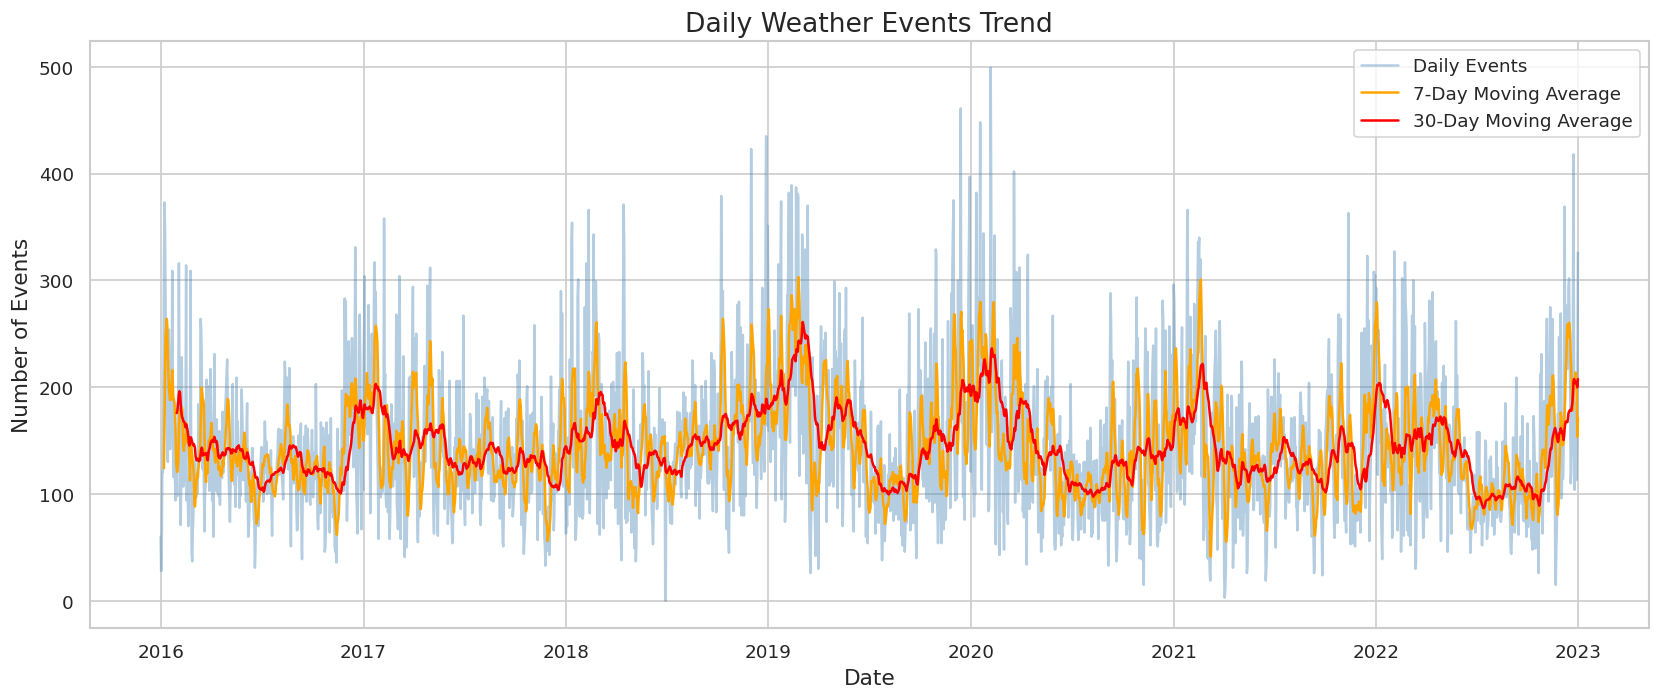

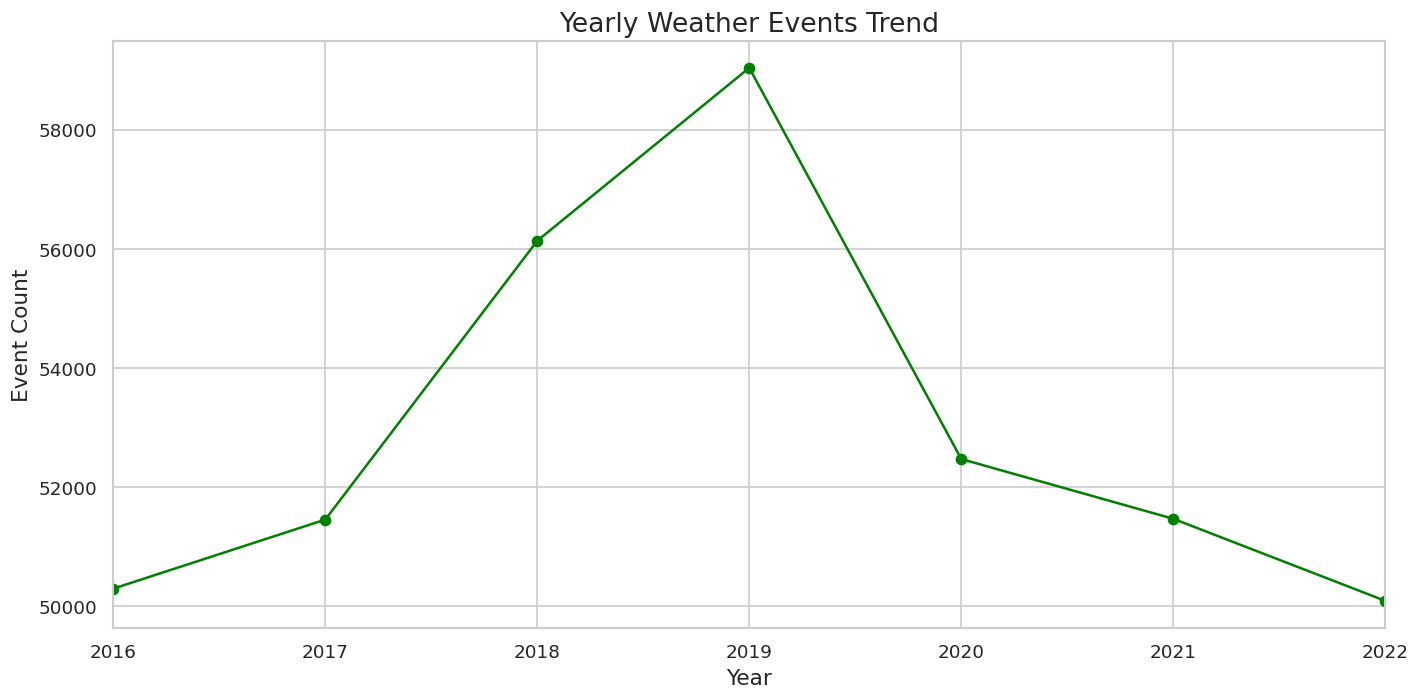

Daily trend statistics saved.
Daily temporal trend analysis complete.


In [ ]:
print("Performing daily temporal trend analysis...\n")

# ensure daily continous TS
daily_events = daily_events.asfreq("D").fillna(0)

# Rolling Trends (Smoothing)
rolling_7 = daily_events.rolling(window=7).mean()
rolling_30 = daily_events.rolling(window=30).mean()

# Save rolling statistics
rolling_stats = pd.DataFrame({
    "DailyEvents": daily_events,
    "RollingMean_7D": rolling_7,
    "RollingMean_30D": rolling_30
})

rolling_stats.to_csv(
    os.path.join(PROJECT_ROOT,"tables","daily_trend_rolling_stats.csv")
)

print("Rolling trend statistics saved.")

# daily trend plot
plt.figure(figsize=(14,6))

plt.plot(
    daily_events,
    label="Daily Events",
    alpha=0.4,
    color="steelblue"
)

plt.plot(
    rolling_7,
    label="7-Day Moving Average",
    color="orange"
)

plt.plot(
    rolling_30,
    label="30-Day Moving Average",
    color="red"
)

plt.title("Daily Weather Events Trend")
plt.xlabel("Date")
plt.ylabel("Number of Events")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"temporal_analysis","daily_trend.png")
)

plt.show()


# yearly aggregated trend
yearly_events = df.resample("Y").size()

plt.figure()

yearly_events.plot(
    marker="o",
    color="green"
)

plt.title("Yearly Weather Events Trend")
plt.xlabel("Year")
plt.ylabel("Event Count")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"temporal_analysis","yearly_trend.png")
)

plt.show()


# daily statistics table
daily_stats = pd.DataFrame({

    "Metric":[
        "Total Days",
        "Average Daily Events",
        "Maximum Daily Events",
        "Minimum Daily Events"
    ],

    "Value":[
        len(daily_events),
        daily_events.mean(),
        daily_events.max(),
        daily_events.min()
    ]

})

daily_stats.to_csv(
    os.path.join(PROJECT_ROOT,"tables","daily_statistics.csv"),
    index=False
)

print("Daily trend statistics saved.")

print("Daily temporal trend analysis complete.")

yearly trend

Performing yearly temporal trend analysis...

Yearly event counts saved.


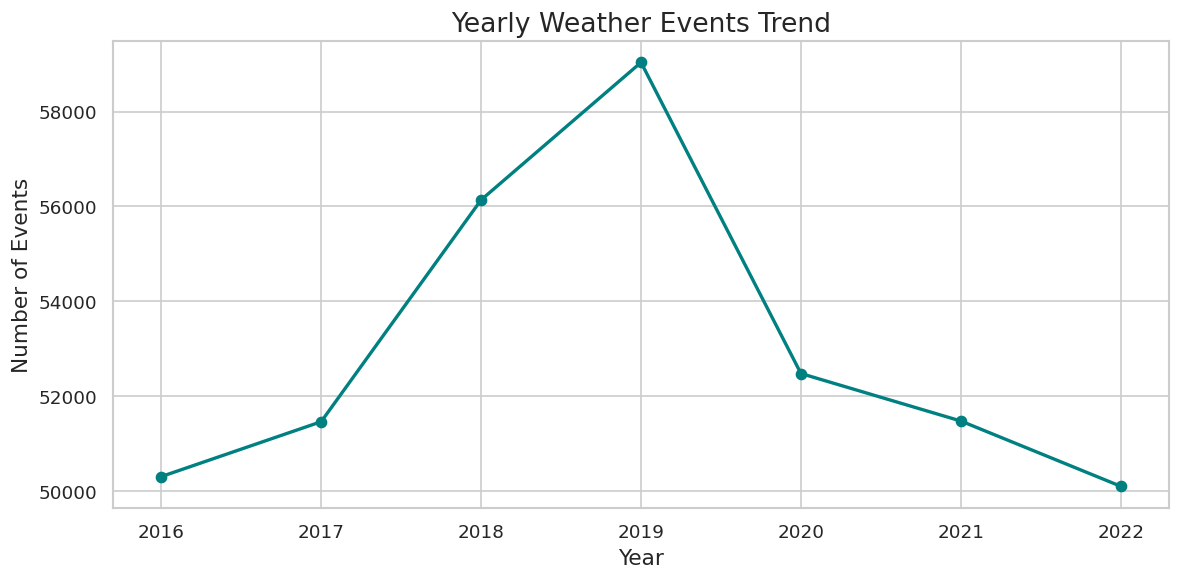

Yearly statistics saved.
Yearly trend analysis complete.


In [ ]:
print("Performing yearly temporal trend analysis...\n")

# yearly event counts
yearly_events = df.resample("Y").size()
yearly_events.name = "EventCount"

# Save yearly counts
yearly_events.to_csv(
    os.path.join(PROJECT_ROOT,"tables","yearly_event_counts.csv")
)

print("Yearly event counts saved.")

# yearly trend plot
plt.figure(figsize=(10,5))

plt.plot(
    yearly_events.index.year,
    yearly_events.values,
    marker="o",
    linewidth=2,
    color="teal"
)

plt.title("Yearly Weather Events Trend")
plt.xlabel("Year")
plt.ylabel("Number of Events")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","yearly_trend.png")
)

plt.show()


# yearly statistics table
yearly_stats = pd.DataFrame({

    "Metric":[
        "Total Years",
        "Average Yearly Events",
        "Maximum Yearly Events",
        "Minimum Yearly Events"
    ],

    "Value":[
        len(yearly_events),
        yearly_events.mean(),
        yearly_events.max(),
        yearly_events.min()
    ]

})

yearly_stats.to_csv(
    os.path.join(PROJECT_ROOT,"tables","yearly_statistics.csv"),
    index=False
)

print("Yearly statistics saved.")

print("Yearly trend analysis complete.")

heatmaps

Generating heatmaps...



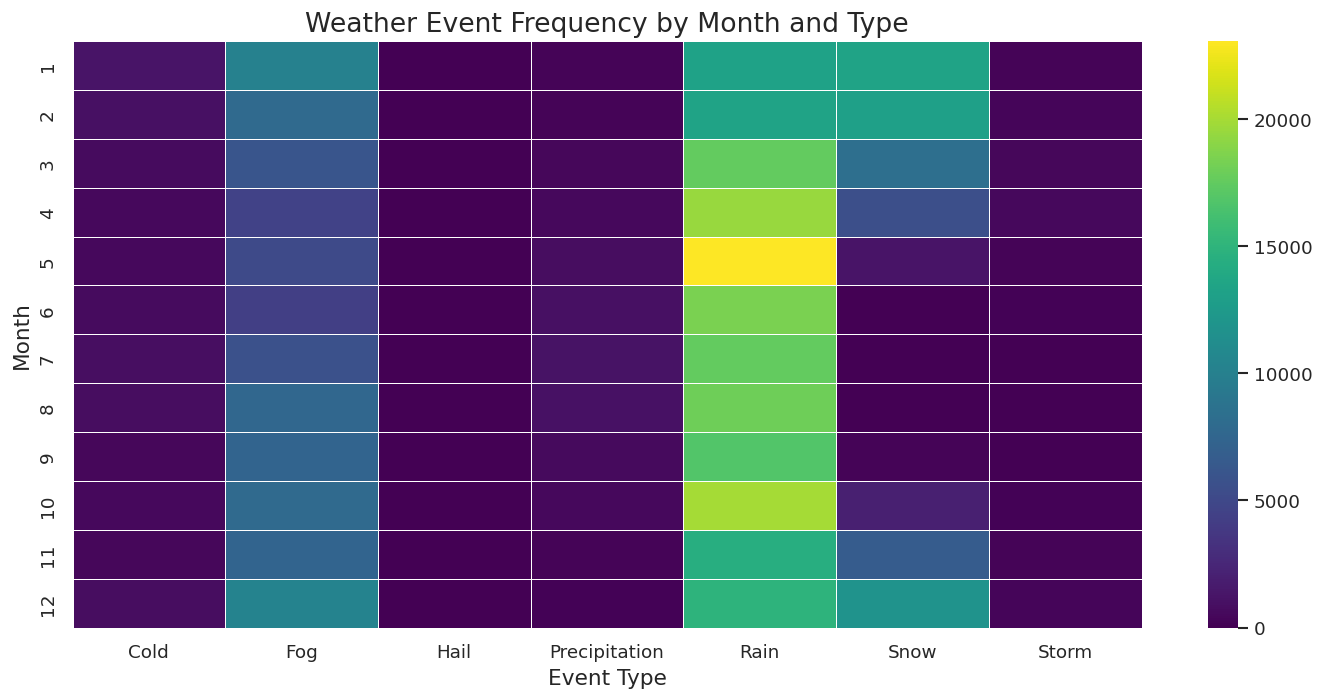

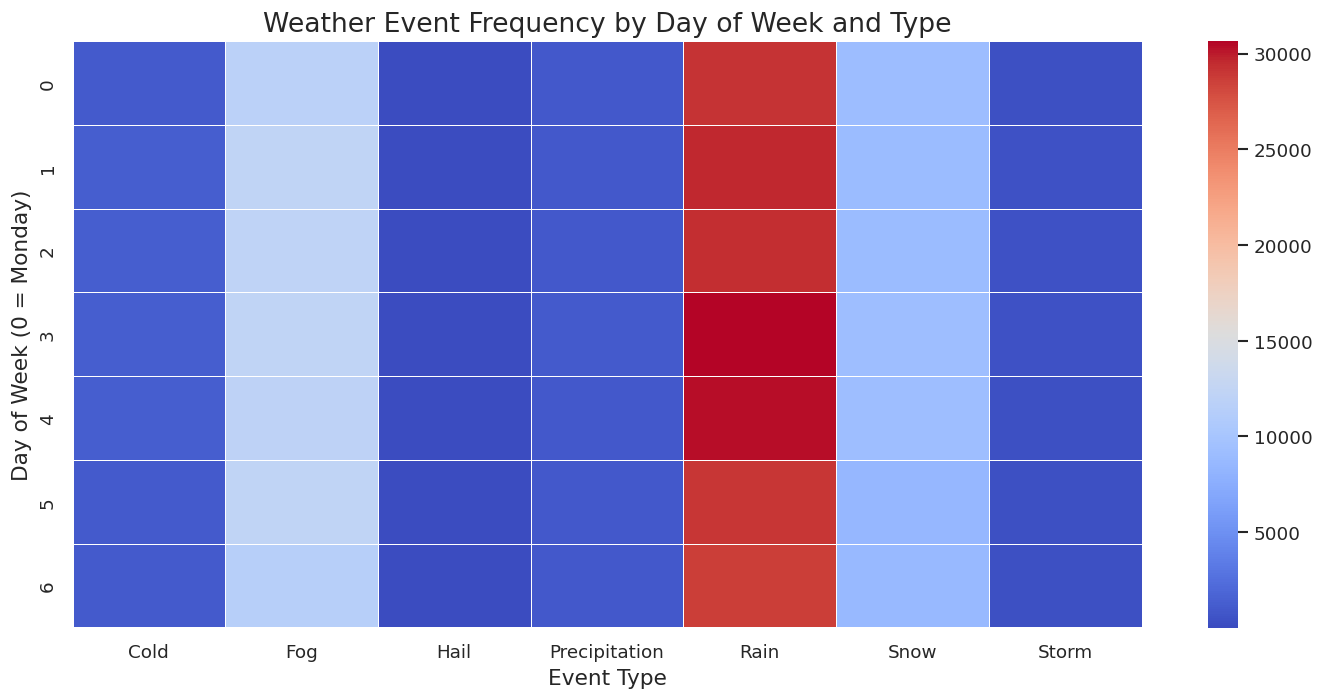

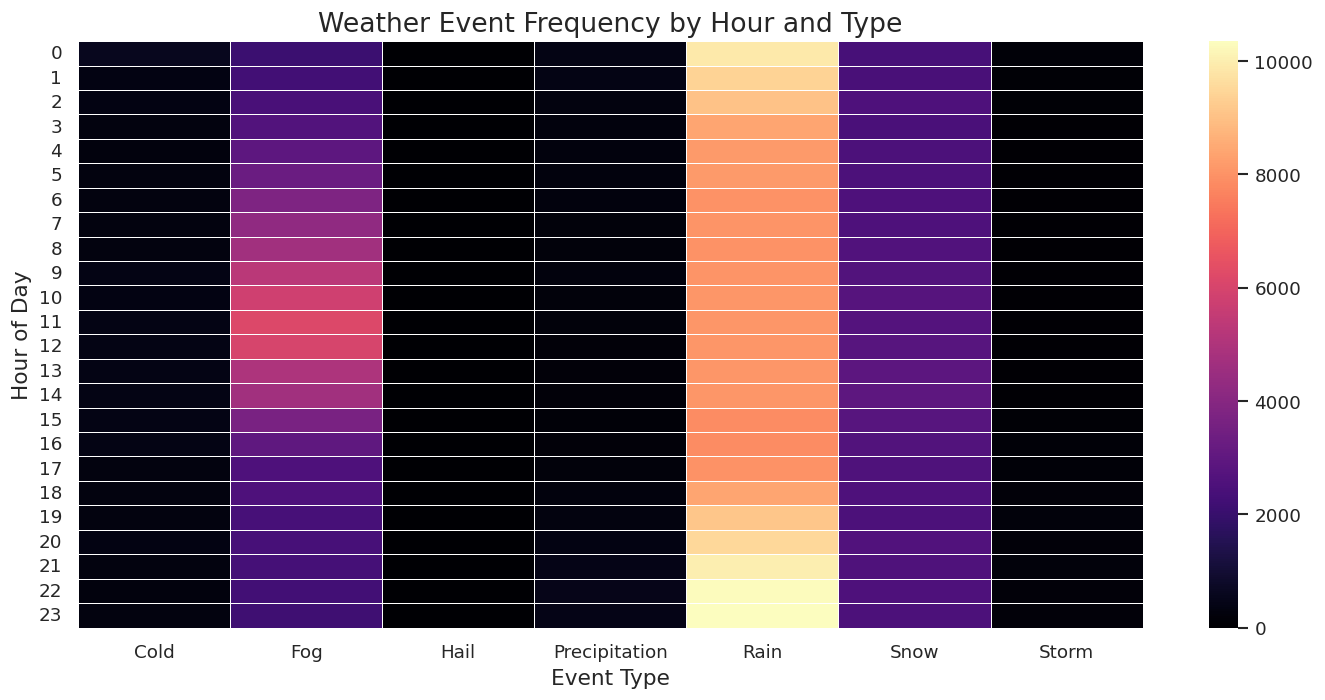

Heatmap analysis complete.


In [ ]:
print("Generating heatmaps...\n")

# event type vs month heatmap
pivot_month_type = pd.pivot_table(
    df,
    values="EventId",
    index="month",
    columns="Type",
    aggfunc="count",
    fill_value=0
)

# Ensure correct month order
pivot_month_type = pivot_month_type.sort_index()

# Save pivot table
pivot_month_type.to_csv(
    os.path.join(PROJECT_ROOT,"tables","event_type_month_pivot.csv")
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_month_type,
    cmap="viridis",
    linewidths=0.5
)

plt.title("Weather Event Frequency by Month and Type")
plt.xlabel("Event Type")
plt.ylabel("Month")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","event_type_month_heatmap.png")
)

plt.show()


# event type vs day of week heatmap
pivot_weekday = pd.pivot_table(
    df,
    values="EventId",
    index="day_of_week",
    columns="Type",
    aggfunc="count",
    fill_value=0
)

pivot_weekday.to_csv(
    os.path.join(PROJECT_ROOT,"tables","event_type_weekday_pivot.csv")
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_weekday,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Weather Event Frequency by Day of Week and Type")
plt.xlabel("Event Type")
plt.ylabel("Day of Week (0 = Monday)")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","event_type_weekday_heatmap.png")
)

plt.show()


# event type vs hour heatmap
pivot_hour = pd.pivot_table(
    df,
    values="EventId",
    index="hour",
    columns="Type",
    aggfunc="count",
    fill_value=0
)

pivot_hour.to_csv(
    os.path.join(PROJECT_ROOT,"tables","event_type_hour_pivot.csv")
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_hour,
    cmap="magma",
    linewidths=0.5
)

plt.title("Weather Event Frequency by Hour and Type")
plt.xlabel("Event Type")
plt.ylabel("Hour of Day")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","event_type_hour_heatmap.png")
)

plt.show()


print("Heatmap analysis complete.")

correlation analysis

Performing correlation analysis...



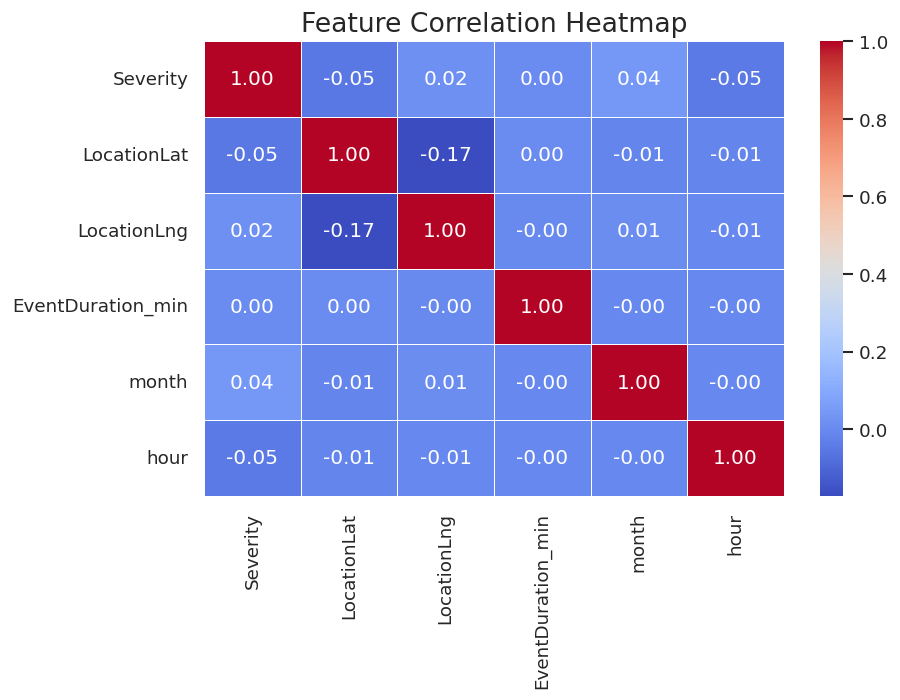

In [ ]:
print("Performing correlation analysis...\n")

# severity mapping
severity_mapping = {
    "Minor": 1,
    "Light": 2,
    "Moderate": 3,
    "Severe": 4,
    "Heavy": 5,
    "Extreme": 6
}

# Create feature subset
features_for_corr = df[
    [
        "Severity",
        "LocationLat",
        "LocationLng",
        "EventDuration_min",
        "month",
        "hour"
    ]
].copy()

# Map severity categories to numeric
features_for_corr["Severity"] = features_for_corr["Severity"].map(severity_mapping)

# Remove rows with missing mapped values
features_for_corr = features_for_corr.dropna()

# correlation matrix
corr_matrix = features_for_corr.corr()

# Save correlation table
corr_matrix.to_csv(
    os.path.join(PROJECT_ROOT,"tables","correlation_matrix.csv")
)

# correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","correlation_matrix.png")
)

plt.show()


# pairplot for feature relationships
sns.pairplot(
    features_for_corr,
    diag_kind="kde"
)

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","feature_pairplot.png")
)

plt.show()


print("Correlation analysis complete.")

time series decomposition

In [ ]:
print("Performing time series decomposition...\n")

# ensure continous daily sereis
daily_series = daily_events.asfreq("D").fillna(0)

# additive decomposition
decomposition = seasonal_decompose(
    daily_series,
    model="additive",
    period=365
)

# Plot full decomposition
fig = decomposition.plot()

fig.set_size_inches(12,8)

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"temporal_analysis","decomposition_full.png")
)

plt.show()


#saving individual components
trend_component = decomposition.trend
seasonal_component = decomposition.seasonal
residual_component = decomposition.resid

# Save components table
components_df = pd.DataFrame({
    "Trend": trend_component,
    "Seasonal": seasonal_component,
    "Residual": residual_component
})

components_df.to_csv(
    os.path.join(PROJECT_ROOT,"tables","decomposition_components.csv")
)

print("Decomposition components saved.")


# trend component plot
plt.figure()

plt.plot(trend_component)

plt.title("Trend Component")
plt.xlabel("Date")
plt.ylabel("Trend")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"temporal_analysis","trend_component.png")
)

plt.show()


# seasonal component plot
plt.figure()

plt.plot(seasonal_component)

plt.title("Seasonal Component")
plt.xlabel("Date")
plt.ylabel("Seasonality")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"temporal_analysis","seasonal_component.png")
)

plt.show()


# residual component plot
plt.figure()

plt.plot(residual_component)

plt.title("Residual Component")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"temporal_analysis","residual_component.png")
)

plt.show()


print("Time series decomposition complete.")

stationarity tests

In [ ]:
print("Running stationarity tests...\n")

# Ensuring continuous daily series
ts = daily_events.asfreq("D").fillna(0)

# adf test
adf_result = adfuller(ts)

# kpps test
kpss_result = kpss(ts, regression="c", nlags="auto")

#stationarity results table
stationarity_table = pd.DataFrame({
    "Test": ["ADF", "KPSS"],
    "Statistic": [adf_result[0], kpss_result[0]],
    "p_value": [adf_result[1], kpss_result[1]],
    "Critical_1%": [adf_result[4]["1%"], kpss_result[3]["1%"]],
    "Critical_5%": [adf_result[4]["5%"], kpss_result[3]["5%"]],
    "Critical_10%": [adf_result[4]["10%"], kpss_result[3]["10%"]]
})

# Determine stationarity
stationarity_table["Stationary"] = [
    adf_result[1] < 0.05,
    kpss_result[1] > 0.05
]

# Save results
stationarity_table.to_csv(
    os.path.join(PROJECT_ROOT,"tables","stationarity_results.csv"),
    index=False
)

display(stationarity_table)

print("Stationarity test results saved.")

autocorrelation analysis

In [ ]:
print("Performing autocorrelation analysis...\n")

# use stationary series
ts = daily_events.asfreq("D").fillna(0)

diff_series = ts.diff().dropna()

# acf plot
plt.figure(figsize=(10,5))

plot_acf(
    diff_series,
    lags=50,
    alpha=0.05
)

plt.title("Autocorrelation Function (ACF)")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"autocorrelation","acf_plot.png")
)

plt.show()


# pacf plot
plt.figure(figsize=(10,5))

plot_pacf(
    diff_series,
    lags=50,
    alpha=0.05,
    method="ywm"
)

plt.title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"autocorrelation","pacf_plot.png")
)

plt.show()


# exporting autocorrelation values
from statsmodels.tsa.stattools import acf, pacf

acf_vals = acf(diff_series, nlags=50)
pacf_vals = pacf(diff_series, nlags=50)

acf_table = pd.DataFrame({
    "Lag": range(len(acf_vals)),
    "ACF": acf_vals
})

pacf_table = pd.DataFrame({
    "Lag": range(len(pacf_vals)),
    "PACF": pacf_vals
})

acf_table.to_csv(
    os.path.join(PROJECT_ROOT,"tables","acf_values.csv"),
    index=False
)

pacf_table.to_csv(
    os.path.join(PROJECT_ROOT,"tables","pacf_values.csv"),
    index=False
)

print("ACF and PACF tables saved.")

print("Autocorrelation analysis complete.")

train test split

In [ ]:
print("Creating train-test split...\n")

# Ensuring continuous daily time series
ts = daily_events.asfreq("D").fillna(0)

# 80-20 split
split_index = int(len(ts) * 0.8)

train = ts[:split_index]
test = ts[split_index:]

split_date = ts.index[split_index]

print(f"Training samples: {len(train)}")
print(f"Testing samples: {len(test)}")
print(f"Split date: {split_date.date()}")

# save datasets
train.to_csv(
    os.path.join(PROJECT_ROOT,"tables","train_timeseries.csv")
)

test.to_csv(
    os.path.join(PROJECT_ROOT,"tables","test_timeseries.csv")
)

print("Train and test datasets saved.")

# visualize train/test split
plt.figure(figsize=(12,6))

plt.plot(train, label="Training Data", color="blue")
plt.plot(test, label="Testing Data", color="orange")

plt.axvline(split_date, color="red", linestyle="--", label="Train/Test Split")

plt.title("Train-Test Split of Weather Event Time Series")
plt.xlabel("Date")
plt.ylabel("Event Count")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"evaluation","train_test_split.png")
)

plt.show()

# train/test summary table
split_summary = pd.DataFrame({

    "Dataset":["Train","Test"],
    "Samples":[len(train),len(test)],
    "Start Date":[train.index.min(),test.index.min()],
    "End Date":[train.index.max(),test.index.max()]
})

split_summary.to_csv(
    os.path.join(PROJECT_ROOT,"tables","train_test_summary.csv"),
    index=False
)

display(split_summary)

print("Train-test split completed.")

linear regression forecast

In [ ]:
print("Training Linear Regression forecasting model...\n")

# preparing training data
train_lr = pd.DataFrame(train)
train_lr["t"] = np.arange(len(train_lr))

# Model
model_lr = LinearRegression()
model_lr.fit(train_lr[["t"]], train_lr["EventCount"])

print("Model trained.")


# preparing test data
test_lr = pd.DataFrame(test)

test_lr["t"] = np.arange(len(train_lr), len(train_lr) + len(test_lr))

# Predictions
pred_lr = model_lr.predict(test_lr[["t"]])

test_lr["Prediction"] = pred_lr


# evaluation metrics
mae_lr = mean_absolute_error(test_lr["EventCount"], pred_lr)
rmse_lr = np.sqrt(mean_squared_error(test_lr["EventCount"], pred_lr))

metrics_lr = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae_lr],
    "RMSE": [rmse_lr]
})

metrics_lr.to_csv(
    os.path.join(PROJECT_ROOT,"tables","linear_regression_metrics.csv"),
    index=False
)

print(metrics_lr)


# saving predictions
test_lr.to_csv(
    os.path.join(PROJECT_ROOT,"tables","linear_regression_predictions.csv")
)


# forecast visualization
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train", color="blue")

plt.plot(test.index, test, label="Test", color="orange")

plt.plot(test.index, pred_lr, label="LR Forecast", color="green")

plt.title("Linear Regression Forecast")

plt.xlabel("Date")
plt.ylabel("Event Count")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"forecasting","linear_regression_forecast.png")
)

plt.show()

print("Linear regression forecasting complete.")

arima model

In [ ]:
print("Training ARIMA model...\n")

# fit arima model
model_arima = ARIMA(train, order=(2,1,2))

fit_arima = model_arima.fit()

print(fit_arima.summary())


# forecast
pred_arima = fit_arima.forecast(steps=len(test))

pred_arima = pd.Series(
    pred_arima,
    index=test.index,
    name="Prediction"
)


# evaluation metrics
mae_arima = mean_absolute_error(test, pred_arima)

rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))

metrics_arima = pd.DataFrame({
    "Model":["ARIMA"],
    "MAE":[mae_arima],
    "RMSE":[rmse_arima]
})

metrics_arima.to_csv(
    os.path.join(PROJECT_ROOT,"tables","arima_metrics.csv"),
    index=False
)

print(metrics_arima)


# saving forecast results
forecast_table = pd.DataFrame({
    "Actual": test,
    "Prediction": pred_arima
})

forecast_table.to_csv(
    os.path.join(PROJECT_ROOT,"tables","arima_predictions.csv")
)


# forcast visualization
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train", color="blue")

plt.plot(test.index, test, label="Test", color="orange")

plt.plot(pred_arima.index, pred_arima, label="ARIMA Forecast", color="green")

plt.title("ARIMA Forecast")

plt.xlabel("Date")
plt.ylabel("Event Count")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"forecasting","arima_forecast.png")
)

plt.show()


#residual diagnostics
residuals = fit_arima.resid

plt.figure(figsize=(10,5))

sns.histplot(residuals, bins=40, kde=True)

plt.title("ARIMA Residual Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"evaluation","arima_residual_distribution.png")
)

plt.show()


print("ARIMA modelling complete.")

auto arima

In [ ]:
print("Running Auto-ARIMA model selection...\n")

# fir auto arima
auto_model = auto_arima(
    train,
    seasonal=True,
    m=7,                 # weekly seasonality
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())


# extracting best parameters
best_order = auto_model.order
best_seasonal_order = auto_model.seasonal_order

params_table = pd.DataFrame({
    "Parameter":["p","d","q","P","D","Q","m"],
    "Value":[
        best_order[0],
        best_order[1],
        best_order[2],
        best_seasonal_order[0],
        best_seasonal_order[1],
        best_seasonal_order[2],
        best_seasonal_order[3]
    ]
})

params_table.to_csv(
    os.path.join(PROJECT_ROOT,"tables","auto_arima_parameters.csv"),
    index=False
)


# forecast
pred_auto = auto_model.predict(n_periods=len(test))

pred_auto = pd.Series(
    pred_auto,
    index=test.index,
    name="Prediction"
)


# evaluation metrics
mae_auto = mean_absolute_error(test, pred_auto)

rmse_auto = np.sqrt(mean_squared_error(test, pred_auto))

metrics_auto = pd.DataFrame({
    "Model":["Auto-ARIMA"],
    "MAE":[mae_auto],
    "RMSE":[rmse_auto]
})

metrics_auto.to_csv(
    os.path.join(PROJECT_ROOT,"tables","auto_arima_metrics.csv"),
    index=False
)

print(metrics_auto)


# saving predictions
forecast_auto = pd.DataFrame({
    "Actual": test,
    "Prediction": pred_auto
})

forecast_auto.to_csv(
    os.path.join(PROJECT_ROOT,"tables","auto_arima_predictions.csv")
)


# forecast visualization

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Test")

plt.plot(pred_auto.index, pred_auto, label="Auto-ARIMA Forecast")

plt.title("Auto-ARIMA Forecast")

plt.xlabel("Date")
plt.ylabel("Event Count")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"forecasting","auto_arima_forecast.png")
)

plt.show()


print("Auto-ARIMA modelling complete.")

sarima

In [ ]:
print("Training SARIMA model...\n")

# fit sarima model
sarima = SARIMAX(
    train,
    order=(2,1,2),
    seasonal_order=(1,1,1,7)
)

fit_sarima = sarima.fit()

print(fit_sarima.summary())


# forecast
pred_sarima = fit_sarima.forecast(steps=len(test))

pred_sarima = pd.Series(
    pred_sarima,
    index=test.index,
    name="Prediction"
)


# evaluation metrics
mae_sarima = mean_absolute_error(test, pred_sarima)

rmse_sarima = np.sqrt(mean_squared_error(test, pred_sarima))

metrics_sarima = pd.DataFrame({
    "Model":["SARIMA"],
    "MAE":[mae_sarima],
    "RMSE":[rmse_sarima]
})

metrics_sarima.to_csv(
    os.path.join(PROJECT_ROOT,"tables","sarima_metrics.csv"),
    index=False
)

print(metrics_sarima)


# saving predictions
forecast_sarima = pd.DataFrame({
    "Actual": test,
    "Prediction": pred_sarima
})

forecast_sarima.to_csv(
    os.path.join(PROJECT_ROOT,"tables","sarima_predictions.csv")
)


# forecast visualization
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Test")

plt.plot(pred_sarima.index, pred_sarima, label="SARIMA Forecast")

plt.title("SARIMA Forecast")

plt.xlabel("Date")
plt.ylabel("Event Count")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"forecasting","sarima_forecast.png")
)

plt.show()


# residual diagnostics
residuals = fit_sarima.resid

plt.figure(figsize=(10,5))

sns.histplot(residuals, bins=40, kde=True)

plt.title("SARIMA Residual Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"evaluation","sarima_residual_distribution.png")
)

plt.show()


print("SARIMA modelling complete.")

prophet model

In [ ]:
print("Training Prophet forecasting model...\n")

# preparing data for prophet
prophet_df = daily_events.reset_index()

prophet_df.columns = ["ds","y"]

# train/test split for prophet
prophet_train = prophet_df.iloc[:len(train)]

prophet_test = prophet_df.iloc[len(train):]

# fit prophet model
prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet.fit(prophet_train)

# forecast
future = prophet.make_future_dataframe(
    periods=len(prophet_test),
    freq="D"
)

forecast = prophet.predict(future)

# Extract predictions for test period
pred_prophet = forecast["yhat"].iloc[-len(prophet_test):]

pred_prophet.index = test.index


# evaluation metrics
mae_prophet = mean_absolute_error(test, pred_prophet)

rmse_prophet = np.sqrt(mean_squared_error(test, pred_prophet))

metrics_prophet = pd.DataFrame({
    "Model":["Prophet"],
    "MAE":[mae_prophet],
    "RMSE":[rmse_prophet]
})

metrics_prophet.to_csv(
    os.path.join(PROJECT_ROOT,"tables","prophet_metrics.csv"),
    index=False
)

print(metrics_prophet)


# saving preedictions
forecast_prophet = pd.DataFrame({
    "Actual": test,
    "Prediction": pred_prophet
})

forecast_prophet.to_csv(
    os.path.join(PROJECT_ROOT,"tables","prophet_predictions.csv")
)


# forecast visualization
fig1 = prophet.plot(forecast)

plt.title("Prophet Forecast")

plt.savefig(
    os.path.join(PROJECT_ROOT,"forecasting","prophet_forecast.png")
)

plt.show()


# prophet components block
fig2 = prophet.plot_components(forecast)

plt.savefig(
    os.path.join(PROJECT_ROOT,"forecasting","prophet_components.png")
)

plt.show()


print("Prophet forecasting complete.")

LSTM deep learning model

In [ ]:
print("Training LSTM forecasting model...\n")

# scaling
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(daily_events.values.reshape(-1,1))


# sequence prep
def create_sequences(data, look_back):

    X, y = [], []

    for i in range(len(data) - look_back):

        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])

    return np.array(X), np.array(y)


look_back = 10

X, y = create_sequences(data_scaled, look_back)


# Train/Test split
train_size_lstm = int(len(X) * 0.8)

X_train = X[:train_size_lstm]
X_test = X[train_size_lstm:]

y_train = y[:train_size_lstm]
y_test = y[train_size_lstm:]


# Reshape for LSTM input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


# LSTM modela architecture
model = Sequential()

# Corrected: Input layer was missing from imports
from tensorflow.keras.layers import Input
model.add(Input(shape=(look_back,1)))

model.add(LSTM(50, return_sequences=False))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)


# training with early stopping
early_stop = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)


# predictions
lstm_predictions_scaled = model.predict(X_test)

pred_lstm = scaler.inverse_transform(lstm_predictions_scaled).flatten()

actual_lstm = scaler.inverse_transform(
    y_test.reshape(-1,1)
).flatten()


# evaluation metrics
mae_lstm = mean_absolute_error(actual_lstm, pred_lstm)

rmse_lstm = np.sqrt(mean_squared_error(actual_lstm, pred_lstm))

metrics_lstm = pd.DataFrame({
    "Model":["LSTM"],
    "MAE":[mae_lstm],
    "RMSE":[rmse_lstm]
})

metrics_lstm.to_csv(
    os.path.join(PROJECT_ROOT,"tables","lstm_metrics.csv"),
    index=False
)

print(metrics_lstm)


# saving predictions
forecast_lstm = pd.DataFrame({
    "Actual": actual_lstm,
    "Prediction": pred_lstm
})

forecast_lstm.to_csv(
    os.path.join(PROJECT_ROOT,"tables","lstm_predictions.csv"),
    index=False
)


# forecast visualization
plt.figure(figsize=(12,6))

plt.plot(actual_lstm, label="Actual")

plt.plot(pred_lstm, label="LSTM Forecast")

plt.title("LSTM Forecast vs Actual")

plt.xlabel("Time")

plt.ylabel("Event Count")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"forecasting","lstm_forecast.png")
)

plt.show()


# training loss curve
plt.figure()

plt.plot(history.history["loss"])

plt.title("LSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"evaluation","lstm_training_loss.png")
)

plt.show()

print("LSTM forecasting complete.")

model comparision table

In [ ]:
print("Generating model comparison...\n")

# helper metrics
def rmse(y_true,y_pred):
    return np.sqrt(mean_squared_error(y_true,y_pred))


def mae(y_true,y_pred):
    return mean_absolute_error(y_true,y_pred)


# Compute Metrics for All Models
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "ARIMA",
        "Auto ARIMA",
        "SARIMA",
        "Prophet",
        "LSTM"
    ],

    "MAE":[
        mae(test,pred_lr),
        mae(test,pred_arima),
        mae(test,pred_auto),
        mae(test,pred_sarima),
        mae(test,pred_prophet),
        mae(actual_lstm,pred_lstm)
    ],

    "RMSE":[
        rmse(test,pred_lr),
        rmse(test,pred_arima),
        rmse(test,pred_auto),
        rmse(test,pred_sarima),
        rmse(test,pred_prophet),
        rmse(actual_lstm,pred_lstm)
    ]
})

# Save table
comparison.to_csv(
    os.path.join(PROJECT_ROOT,"tables","model_comparison.csv"),
    index=False
)

display(comparison)


# RMSE Comparison Plot
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="RMSE",
    data=comparison
)

plt.title("Model RMSE Comparison")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"evaluation","rmse_comparison.png")
)

plt.show()


# MAE Comparison Plot
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="MAE",
    data=comparison
)

plt.title("Model MAE Comparison")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"evaluation","mae_comparison.png")
)

plt.show()


print("Model comparison completed.")

model evaluation

In [ ]:
print("Evaluating forecasting models...\n")

# evaluation function
def evaluate(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"{model_name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print()

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse
    }


# evaluating all models
results = []

results.append(evaluate(test, pred_lr, "Linear Regression"))
results.append(evaluate(test, pred_arima, "ARIMA"))
results.append(evaluate(test, pred_auto, "Auto-ARIMA"))
results.append(evaluate(test, pred_sarima, "SARIMA"))
results.append(evaluate(test, pred_prophet, "Prophet"))

# LSTM alignment
results.append(evaluate(actual_lstm, pred_lstm, "LSTM"))


# create rresults table
evaluation_table = pd.DataFrame(results)

evaluation_table.to_csv(
    os.path.join(PROJECT_ROOT,"tables","model_evaluation_metrics.csv"),
    index=False
)

display(evaluation_table)


# RMSE Comparison Plot
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="RMSE",
    data=evaluation_table
)

plt.title("RMSE Comparison Across Models")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"evaluation","rmse_comparison.png")
)

plt.show()


# MAE Comparison Plot
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="MAE",
    data=evaluation_table
)

plt.title("MAE Comparison Across Models")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"evaluation","mae_comparison.png")
)

plt.show()

print("Model evaluation completed.")

forecast comparision plot

In [ ]:
print("Generating final forecast comparison plot...\n")

plt.figure(figsize=(14,6))

# Actual Series
plt.plot(train.index, train, label="Train", color="black")

plt.plot(test.index, test, label="Test", color="blue")


# Forecasts
plt.plot(test.index, pred_lr, label="Linear Regression", linestyle="--")

plt.plot(test.index, pred_arima, label="ARIMA", linestyle="--")

plt.plot(test.index, pred_auto, label="Auto-ARIMA", linestyle="--")

plt.plot(test.index, pred_sarima, label="SARIMA", linestyle="--")

plt.plot(test.index, pred_prophet, label="Prophet", linestyle="--")


# LSTM predictions (aligned separately)
plt.plot(
    test.index[:len(pred_lstm)],
    pred_lstm,
    label="LSTM",
    linestyle="--"
)


# Formatting
plt.title("Forecast Comparison Across Models")

plt.xlabel("Date")

plt.ylabel("Weather Event Count")

plt.legend(loc="upper left")

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","forecast_model_comparison.png")
)

plt.show()

print("Forecast comparison visualization saved.")